In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load training data
train_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')

# Check dataset dimensions
print(f"Dataset Shape: {train_df.shape}")

# View the first 5 rows
train_df.head()

Dataset Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Analyzing the Target Variable (SalePrice)
Before looking at feature variables, we explore the distribution of house prices in Ames, Iowa, to check for skewness.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


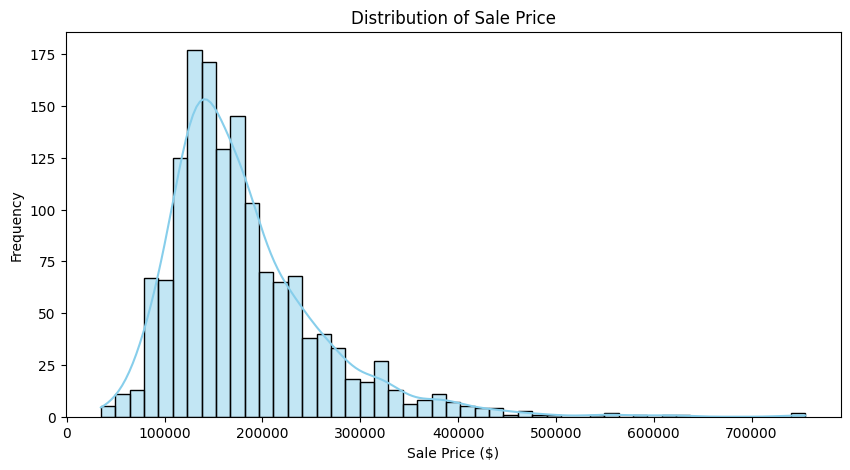

Skewness: 1.88


In [3]:
# 1. Summary statistics of SalePrice
print(train_df['SalePrice'].describe())

# 2. Visualize SalePrice distribution
plt.figure(figsize=(10, 5))
sns.histplot(train_df['SalePrice'], kde=True, color='skyblue')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.show()

# 3. Check Skewness
print(f"Skewness: {train_df['SalePrice'].skew():.2f}")

Here the skewness is greater than 1.0, it means most houses sell at moderate prices,

## Top Correlated Features with SalePrice
We analyze which numerical variables have the strongest correlation with house prices to guide feature selection.

Top 10 Features Correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


/tmp/ipykernel_58/701218063.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='viridis')


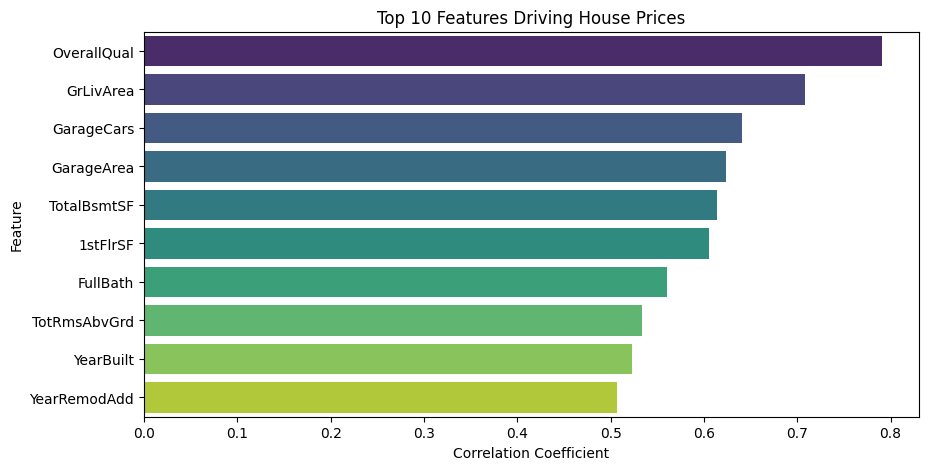

In [4]:
# 1. Filter for numerical features
numeric_features = train_df.select_dtypes(include=[np.number])

# 2. Compute correlation matrix
corr_matrix = numeric_features.corr()

# 3. Get top 10 features most correlated with SalePrice
top_corr_features = corr_matrix['SalePrice'].sort_values(ascending=False)[1:11]

print("Top 10 Features Correlated with SalePrice:")
print(top_corr_features)

# 4. Plot top correlations
plt.figure(figsize=(10, 5))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='viridis')
plt.title('Top 10 Features Driving House Prices')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.show()

## Missing Value Analysis
We identify missing values across all features to determine our data cleaning strategy.

Columns with Missing Values:
              Missing Count  Percentage (%)
PoolQC                 1453       99.520548
MiscFeature            1406       96.301370
Alley                  1369       93.767123
Fence                  1179       80.753425
MasVnrType              872       59.726027
FireplaceQu             690       47.260274
LotFrontage             259       17.739726
GarageType               81        5.547945
GarageYrBlt              81        5.547945
GarageFinish             81        5.547945
GarageQual               81        5.547945
GarageCond               81        5.547945
BsmtExposure             38        2.602740
BsmtFinType2             38        2.602740
BsmtQual                 37        2.534247


/tmp/ipykernel_58/2749738266.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.head(10).values, y=missing_pct.head(10).index, palette='magma')


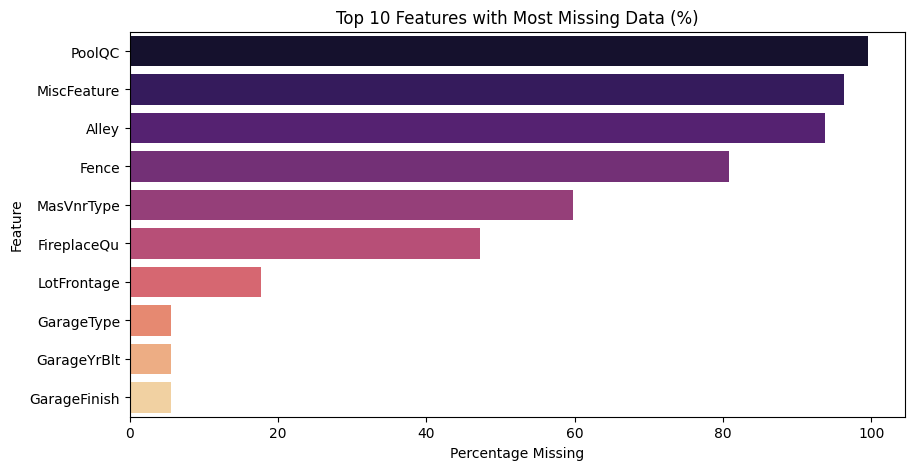

In [5]:
# 1. Find columns with missing values and calculate percentage
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_df)) * 100

missing_data = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print("Columns with Missing Values:")
print(missing_data.head(15))

# 2. Visualize top missing features
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_pct.head(10).values, y=missing_pct.head(10).index, palette='magma')
plt.title('Top 10 Features with Most Missing Data (%)')
plt.xlabel('Percentage Missing')
plt.ylabel('Feature')
plt.show()

## Data Cleaning & Missing Value Imputation
We fill missing values based on feature logic: categorical columns missing attributes mean 'None', while missing numerical attributes are filled with 0 or median values.

In [6]:
# Create a copy of the dataset to clean
train_clean = train_df.copy()

# 1. Fill categorical columns where NA means 'None' / feature doesn't exist
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    train_clean[col] = train_clean[col].fillna('None')

# 2. Fill numerical columns where NA means 0 (no garage, no veneer, etc.)
zero_cols = ['GarageYrBlt', 'GarageCars', 'GarageArea', 'BsmtFinSF1', 
             'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']

for col in zero_cols:
    train_clean[col] = train_clean[col].fillna(0)

# 3. Fill LotFrontage with median of the neighborhood
train_clean['LotFrontage'] = train_clean.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# 4. Fill any remaining categorical missing values with the mode (most common value)
train_clean['Electrical'] = train_clean['Electrical'].fillna(train_clean['Electrical'].mode()[0])

# Verify no missing values remain
print(f"Remaining Missing Values: {train_clean.isnull().sum().sum()}")

Remaining Missing Values: 0


## Feature Engineering & Target Transformation
We combine related size metrics into unified feature columns and apply a log transformation (`log1p`) to `SalePrice` to fix its right skewness for linear modeling.

In [7]:
# 1. Create Total Square Footage feature
train_clean['TotalSF'] = train_clean['TotalBsmtSF'] + train_clean['1stFlrSF'] + train_clean['2ndFlrSF']

# 2. Create Total Bathrooms feature
train_clean['TotalBathrooms'] = (train_clean['FullBath'] + (0.5 * train_clean['HalfBath']) +
                                 train_clean['BsmtFullBath'] + (0.5 * train_clean['BsmtHalfBath']))

# 3. Create Total Porch/Deck Square Footage
train_clean['TotalPorchSF'] = (train_clean['OpenPorchSF'] + train_clean['EnclosedPorch'] +
                               train_clean['3SsnPorch'] + train_clean['ScreenPorch'] + train_clean['WoodDeckSF'])

# 4. Create Age features
train_clean['HouseAge'] = train_clean['YrSold'] - train_clean['YearBuilt']
train_clean['RemodAge'] = train_clean['YrSold'] - train_clean['YearRemodAdd']

# 5. Log-transform the Target Variable (SalePrice)
train_clean['SalePrice_Log'] = np.log1p(train_clean['SalePrice'])

# Display new correlation with SalePrice_Log
new_corrs = train_clean[['TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge', 'RemodAge', 'SalePrice_Log']].corr()['SalePrice_Log']
print("Correlations of newly engineered features with Log SalePrice:")
print(new_corrs.sort_values(ascending=False))

Correlations of newly engineered features with Log SalePrice:
SalePrice_Log     1.000000
TotalSF           0.777297
TotalBathrooms    0.673011
TotalPorchSF      0.398387
RemodAge         -0.568136
HouseAge         -0.587290
Name: SalePrice_Log, dtype: float64


## Categorical Encoding (One-Hot Encoding)
Machine learning models require numerical inputs. We convert remaining categorical text features into binary indicator variables using One-Hot Encoding.

In [8]:
# Select categorical columns
categorical_cols = train_clean.select_dtypes(include=['object']).columns

print(f"Total Categorical Columns to Encode: {len(categorical_cols)}")

# Apply One-Hot Encoding
train_encoded = pd.get_dummies(train_clean, drop_first=True)

print(f"Dataset shape after encoding: {train_encoded.shape}")

Total Categorical Columns to Encode: 43
Dataset shape after encoding: (1460, 267)


## Model Preparation & Train-Validation Split
We separate our predictor features from our log-transformed target variable (`SalePrice_Log`), drop non-predictive columns like `Id`, and split our data into training and validation sets.

In [9]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
X = train_encoded.drop(columns=['Id', 'SalePrice', 'SalePrice_Log'])
y = train_encoded['SalePrice_Log']

# 2. Split into Train (80%) and Validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

Training features shape: (1168, 264)
Validation features shape: (292, 264)


## Model Training & Validation (Ridge Regression)
We train a Ridge Regression model on our training data and measure its performance on the validation set using Root Mean Squared Error (RMSE) on the log-transformed target scale.

Validation RMSE (Log Scale): 0.1390


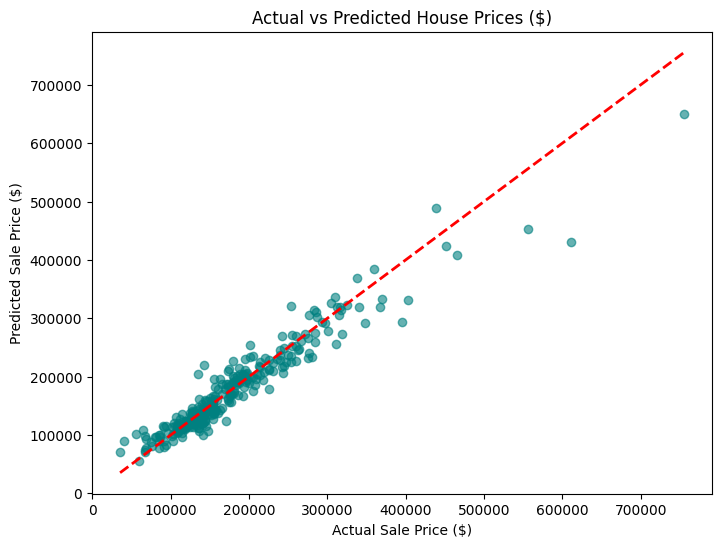

In [10]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# 1. Initialize and fit Ridge Regression model
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train, y_train)

# 2. Predict on validation set
val_preds_log = ridge_model.predict(X_val)

# 3. Calculate RMSE on log scale
rmse_log = np.sqrt(mean_squared_error(y_val, val_preds_log))
print(f"Validation RMSE (Log Scale): {rmse_log:.4f}")

# 4. Plot Actual vs Predicted Prices (converted back to actual dollars)
val_preds_actual = np.expm1(val_preds_log)
y_val_actual = np.expm1(y_val)

plt.figure(figsize=(8, 6))
plt.scatter(y_val_actual, val_preds_actual, alpha=0.6, color='teal')
plt.plot([y_val_actual.min(), y_val_actual.max()], [y_val_actual.min(), y_val_actual.max()], 'r--', lw=2)
plt.title('Actual vs Predicted House Prices ($)')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.show()

## Preprocessing Test Data & Generating Kaggle Submission
We align and apply the complete data pipeline (imputation, feature engineering, and one-hot encoding) to `test.csv`, generate predictions using our trained Ridge model, and export `submission.csv`.

In [11]:
# 1. Load test data
test_df = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

# 2. Impute missing values in test set
test_clean = test_df.copy()

for col in none_cols:
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].fillna('None')

for col in zero_cols:
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].fillna(0)

# Fill remaining test-specific missing values
test_clean['LotFrontage'] = test_clean.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
test_clean['MSZoning'] = test_clean['MSZoning'].fillna(test_clean['MSZoning'].mode()[0])
test_clean['Utilities'] = test_clean['Utilities'].fillna('AllPub')
test_clean['Exterior1st'] = test_clean['Exterior1st'].fillna(test_clean['Exterior1st'].mode()[0])
test_clean['Exterior2nd'] = test_clean['Exterior2nd'].fillna(test_clean['Exterior2nd'].mode()[0])
test_clean['KitchenQual'] = test_clean['KitchenQual'].fillna(test_clean['KitchenQual'].mode()[0])
test_clean['Functional'] = test_clean['Functional'].fillna('Typ')
test_clean['SaleType'] = test_clean['SaleType'].fillna(test_clean['SaleType'].mode()[0])

# 3. Apply Feature Engineering to test set
test_clean['TotalSF'] = test_clean['TotalBsmtSF'] + test_clean['1stFlrSF'] + test_clean['2ndFlrSF']
test_clean['TotalBathrooms'] = (test_clean['FullBath'] + (0.5 * test_clean['HalfBath']) +
                                test_clean['BsmtFullBath'] + (0.5 * test_clean['BsmtHalfBath']))
test_clean['TotalPorchSF'] = (test_clean['OpenPorchSF'] + test_clean['EnclosedPorch'] +
                              test_clean['3SsnPorch'] + test_clean['ScreenPorch'] + test_clean['WoodDeckSF'])
test_clean['HouseAge'] = test_clean['YrSold'] - test_clean['YearBuilt']
test_clean['RemodAge'] = test_clean['YrSold'] - test_clean['YearRemodAdd']

# 4. One-Hot Encode test data and align columns with training features
test_encoded = pd.get_dummies(test_clean)
X_test = test_encoded.reindex(columns=X.columns, fill_value=0)

# 5. Predict on test set and convert from log scale back to actual dollars
test_preds_log = ridge_model.predict(X_test)
test_preds_actual = np.expm1(test_preds_log)

# 6. Create Submission DataFrame & Save CSV
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_preds_actual
})

submission.to_csv('submission.csv', index=False)
print("submission.csv successfully generated!")
print(submission.head())

submission.csv successfully generated!
     Id      SalePrice
0  1461  111059.319363
1  1462  145151.267139
2  1463  168582.866131
3  1464  190209.278332
4  1465  196760.317242
